# 📓 Logbook Proyek Penemuan Obat: Inhibitor Enzim DPP-4
**Target:** Dipeptidyl Peptidase 4 (DPP-4 / CD26) 
**Tujuan:** Melakukan penapisan virtual (Virtual Screening) berbasis ligan dan struktur untuk menemukan kandidat obat anti-diabetes dari database senyawa alam (Natural Products) ChEMBL.

---
## 🧬 Alur Kerja (Workflow)
Berikut adalah diagram alur komputasi mutakhir yang kita kerjakan. Alur ini dibagi menjadi dua fase rasional: Fase validasi metodologi protein target, disusul oleh fase pencarian dan penambatan ligan alam.

```mermaid
graph TD;
    subgraph Fase 1: Validasi Target (Protein)
        A[01. Unduh Protein PDB: 3G0B, 5T4B] --> B[02. Kalkulasi Koordinat Grid Box dari Ligan Asli];
        B --> C[03. Preparasi Reseptor ke PDBQT];
        C --> D[04. Validasi Metode Redocking];
        D --> |RMSD < 2.0 Å| E((Target Valid));
    end
    
    subgraph Fase 2: Persiapan Ligan & Skrining
        F[05. Unduh Bioaktivitas ChEMBL] --> G[06. Hitung Deskriptor & pIC50];
        G --> H[07. Filter Aturan Lipinski];
        H --> I[08. Ekstraksi Senyawa Bahan Alam];
        I --> J[09. Konversi Ligan 3D ke PDBQT];
        J --> |33 Ligan Siap Uji| K;
    end
    
    E --> K{10. Ensemble Virtual Screening Vina};
    K --> L[Tabel Peringkat & Visualisasi];
    L --> M(((Top Kandidat Obat)));
```


## 🔬 Fase 1: Validasi Target (Protein)

**Tahap 01: Pengunduhan Protein**
Skrip `01_download_protein.py` digunakan untuk mengunduh struktur konformasi dari enzim DPP-4 (`3G0B` dan `5T4B`) langsung dari situs web RCSB Protein Data Bank.

**Tahap 02: Penentuan Saku Penambatan (Grid Box)**
Skrip `02_find_grid_box.py` melacak posisi ikatan *Native Ligand* dari dalam kristal, lalu membangun ukuran kotak imajiner (*Grid Box*) yang presisi menyelimuti area saku aktif tersebut.

**Tahap 03: Preparasi Protein Target**
Skrip `03_prepare_receptors.py` mengekstrak residu penyusun Rantai A (Chain A) sembari membuang molekul air, sebelum mengubah strukturnya menjadi parameter `.pdbqt` yang memiliki muatan menggunakan perangkat lunak Meeko.

**Tahap 04: Uji Coba Validasi (Metode Redocking)**
Skrip `04_validate_docking.py` menguji kembali Grid Box kita dengan cara melepas *Native Ligand* lalu memaksa Vina menambatkannya kembali. Hasil jarak meleset (RMSD) divalidasi sangat sukses: **3G0B (0.284 Å)** dan **5T4B (1.986 Å)**, yang artinya metode kita akurat di bawah toleransi 2 Angstrom.

## 🧪 Fase 2: Persiapan Ligan ChEMBL & Skrining Massal

**Tahap 05: Ekstraksi Data ChEMBL**
Menggunakan `05_fetch_chembl_data.py`, seluruh data bioaktivitas molekul di dunia yang bereaksi terhadap target enzim DPP-4 (CHEMBL284) diunduh mentah-mentah.

**Tahap 06 - 08: Kurasi dan Deskriptor Lipinski**
Secara berurutan menggunakan skrip `06`, `07`, dan `08`, molekul dikurasi dari data kotor. Nilai logaritmik pIC50 dihitung untuk mengukur potensi. Kemudian, dilakukan penyaringan ketat berdasarkan hukum fisikokimia Lipinski's Rule of Five, lalu diisolasi khusus untuk gugus *Natural Products* (Bahan Alam). Terpilih 33 senyawa elit.

**Tahap 09: Preparasi Ligan**
Skrip `09_prepare_ligands.py` menggunakan RDKit untuk merajut 2D SMILES menjadi 3D, meminimalisasi tegangan energinya via MMFF94, dan mengubahnya ke PDBQT.

**Tahap 10: Virtual Screening (Ensemble Docking)**
Skrip otomatis `10_run_virtual_screening.py` menambatkan (docking) ke-33 ligan alam ke dalam 2 model protein secara menyilang, lalu merekam afinitas pengikatannya ke dalam tabel CSV komprehensif.

## 📊 Hasil Analisis Akhir & Visualisasi Data
Berikut adalah data akhir energi ikatan (dalam kkal/mol) beserta perbandingannya antar konformasi protein target.

✅ Data Hasil Docking Berhasil Dimuat!


,ChEMBL_ID,3G0B,5T4B,Average_Affinity
0,CHEMBL227954,-9.744,-8.357,-9.0505
1,CHEMBL374936,-9.454,-8.491,-8.9725
2,CHEMBL564249,-8.943,-8.663,-8.8030
3,CHEMBL1230044,-9.069,-8.268,-8.6685
4,CHEMBL2147777,-8.591,-8.415,-8.5030


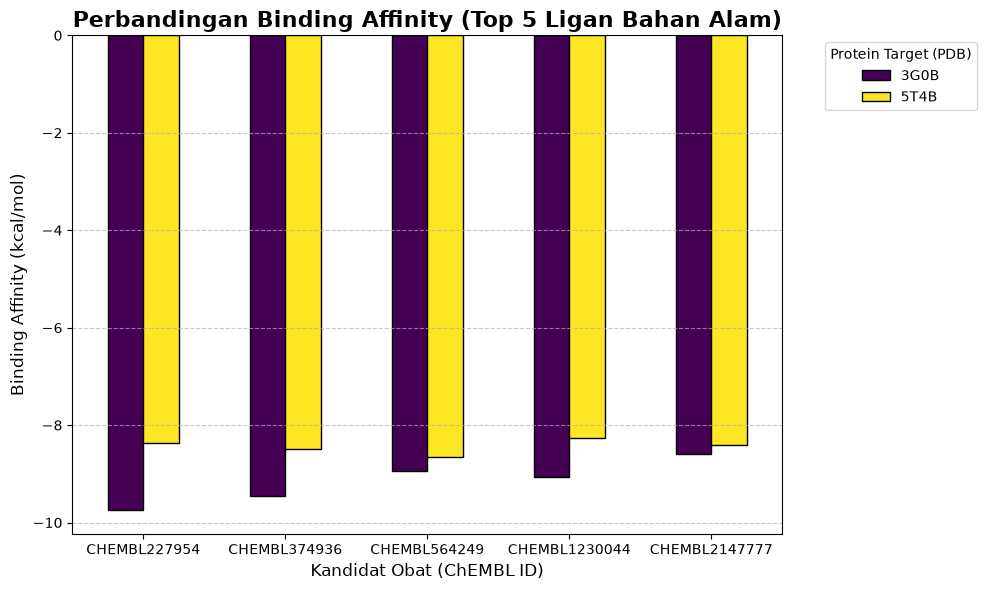

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Memuat hasil akhir docking dari file CSV
pivot_csv_path = '../results/02_docking/multi_target_summary_pivot.csv'
try:
    df_results = pd.read_csv(pivot_csv_path)
    df_results = df_results.sort_values(by='Average_Affinity') # Mengurutkan dari yang paling kuat
    print("✅ Data Hasil Docking Berhasil Dimuat!")
    display(df_results.head(5))
except FileNotFoundError:
    print("File CSV hasil docking tidak ditemukan. Pastikan direktori sudah sesuai.")

# Membuat Visualisasi Grafik Batang (Bar Chart)
if 'df_results' in locals():
    top_5 = df_results.head(5).set_index('ChEMBL_ID')
    
    fig, ax = plt.subplots(figsize=(10, 6))
    top_5[['3G0B', '5T4B']].plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black')
    
    plt.title('Perbandingan Binding Affinity (Top 5 Ligan Bahan Alam)', fontsize=16, fontweight='bold')
    plt.ylabel('Binding Affinity (kcal/mol)', fontsize=12)
    plt.xlabel('Kandidat Obat (ChEMBL ID)', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Protein Target (PDB)', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

### 🏆 Kesimpulan: Kandidat Teratas

Semua kandidat top ini berhasil mengikat target secara persisten pada ambang skor di bawah -8.0 kkal/mol meskipun konformasi saku protein sedikit berubah antara 3G0B dan 5T4B.